In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x = np.array([225,171,198,189,135,162,135,117,162,189])
def NR_ML_Cauchy(t,E,Imax=100):
    Sol = t
    e = 1
    k = 0
    while e > E and k < Imax:
        w = 2 / (1 + (x - t)**2)
        f = -(np.sum(w*(x - t)))
        df = np.sum(w*(1-(w*((x - t)**2))))
        t_k = t - f/df
        e = abs(t_k - t)/max(1, abs(t_k))
        t = t_k
        k += 1
    return t,e,k

In [3]:
#Usando el promedio de la muestra como solución de parámetro (theta) inicial
t,e,k = NR_ML_Cauchy(168.3,10**-12)
print("Valor inicial: 168.3")
print("Solución: " ,t)
print("Log-verosimilitud:", -len(x)*np.log(np.pi) - np.sum(np.log(1 + (x - t)**2)))
print("Error relativo: ",e)
print("Iteración encontrada: ",k)

Valor inicial: 168.3
Solución:  167.69681461998024
Log-verosimilitud: -69.90862387733668
Error relativo:  5.182781058491264e-13
Iteración encontrada:  4


In [4]:
#Prueba de que el algoritmo converge a distintas soluciones y realiza múltiples iteraciones
t,e,k = NR_ML_Cauchy(160,10**-12)
print(t)
print(e)
print(k)

145.0410720610784
1.9595628346179976e-16
7


In [5]:
#Verificación si máximos locales son máximos globales
#Particion tamaño n
a = np.min(x)
b = np.max(x)
n = 5*len(x)
iniciales = []
for j in range(0,n+1):
    iniciales.append(a + j*((b-a)/n))
iniciales = np.array(iniciales)
print(iniciales)
raices = []
errores = []
iteraciones = []
ML = []
for i in range(0,len(iniciales)):
    t,e,k = NR_ML_Cauchy(iniciales[i],10**-12)
    raices.append(t)
    errores.append(e)
    iteraciones.append(k)
    ML.append(-len(x)*np.log(np.pi) - np.sum(np.log(1+((x - t)**2))))
tabla = pd.DataFrame({"Initial input": iniciales,"Root": raices,"Relative error": errores,"Iterations": iteraciones,"Log-likelihood": ML})

[117.   119.16 121.32 123.48 125.64 127.8  129.96 132.12 134.28 136.44
 138.6  140.76 142.92 145.08 147.24 149.4  151.56 153.72 155.88 158.04
 160.2  162.36 164.52 166.68 168.84 171.   173.16 175.32 177.48 179.64
 181.8  183.96 186.12 188.28 190.44 192.6  194.76 196.92 199.08 201.24
 203.4  205.56 207.72 209.88 212.04 214.2  216.36 218.52 220.68 222.84
 225.  ]


In [6]:
tabla

,Initial input,Root,Relative error,Iterations,Log-likelihood
0,117.00,117.237736,0.000000e+00,5,-81.429799
1,119.16,120.597457,0.000000e+00,6,-82.393306
2,121.32,120.597457,1.178371e-16,5,-82.393306
3,123.48,120.597457,3.181602e-15,6,-82.393306
4,125.64,120.597457,4.371756e-14,6,-82.393306
5,127.80,120.597457,0.000000e+00,6,-82.393306
6,129.96,120.597457,9.639075e-14,7,-82.393306
7,132.12,120.597457,3.299439e-15,7,-82.393306
8,134.28,145.041072,2.351475e-15,8,-77.043649
9,136.44,145.041072,1.959563e-16,7,-77.043649


In [7]:
uroot = np.unique(ML)
uroot

array([-85.69518744, -84.26018046, -82.39330646, -81.42979867,
       -77.04364872, -73.34682361, -73.15263331, -69.90862388,
       -68.69675589, -65.28564111])

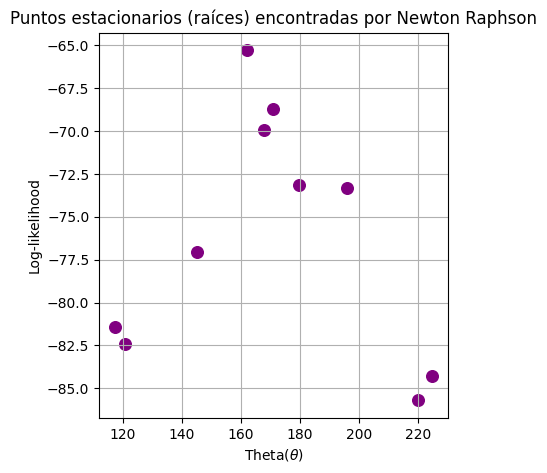

In [8]:
tabla["Root_round"] = tabla["Root"].round(6)
utabla = tabla.drop_duplicates(subset="Root_round")
plt.figure(figsize=(4.5,5))
plt.scatter(
    utabla["Root"],
    utabla["Log-likelihood"],
    s=70,c='purple')
plt.xlabel(r"Theta($\theta$)")
plt.ylabel("Log-likelihood")
plt.title("Puntos estacionarios (raíces) encontradas por Newton Raphson")
plt.grid(True)
plt.show()

In [9]:
utabla

,Initial input,Root,Relative error,Iterations,Log-likelihood,Root_round
0,117.00,117.237736,0.000000e+00,5,-81.429799,117.237736
1,119.16,120.597457,0.000000e+00,6,-82.393306,120.597457
8,134.28,145.041072,2.351475e-15,8,-77.043649,145.041072
21,162.36,162.066509,0.000000e+00,5,-65.285641,162.066509
22,164.52,167.696815,8.643618e-15,5,-69.908624,167.696815
25,171.00,170.865822,1.613492e-14,4,-68.696756,170.865822
26,173.16,179.647889,0.000000e+00,6,-73.152633,179.647889
33,188.28,195.936771,0.000000e+00,7,-73.346824,195.936771
38,199.08,220.134025,4.157372e-14,8,-85.695187,220.134025
50,225.00,224.819319,7.226180e-13,4,-84.260180,224.819319


In [10]:
len(utabla)

10

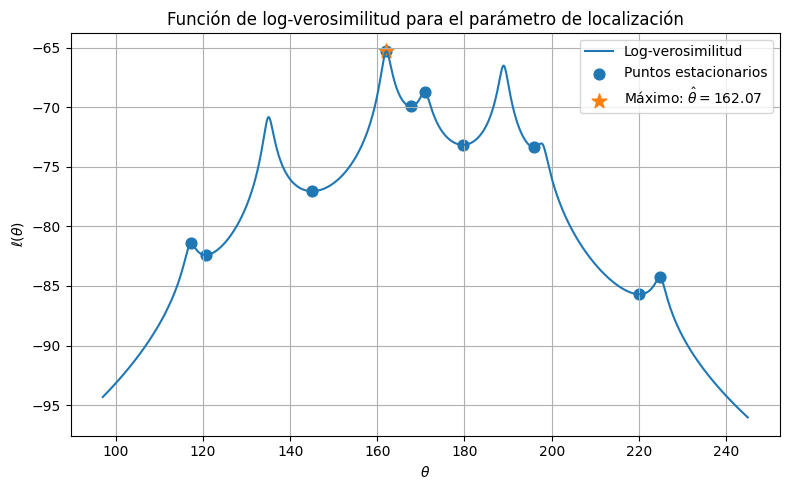

In [11]:

def log_verosimilitud(theta):
    return -len(x)*np.log(np.pi) - np.sum(np.log(1 + (x - theta)**2))

# Rango de theta para graficar
theta_grid = np.linspace(np.min(x) - 20, np.max(x) + 20, 3000)

# Evaluación de la log-verosimilitud en la grilla
loglik_grid = np.array([log_verosimilitud(theta) for theta in theta_grid])

# Punto de máxima log-verosimilitud entre las raíces encontradas
idx_max = utabla["Log-likelihood"].idxmax()
theta_hat = utabla.loc[idx_max, "Root"]
loglik_hat = utabla.loc[idx_max, "Log-likelihood"]

plt.figure(figsize=(8, 5))

# Curva completa
plt.plot(theta_grid, loglik_grid, label="Log-verosimilitud")

# Puntos estacionarios encontrados por Newton-Raphson
plt.scatter(
    utabla["Root"],
    utabla["Log-likelihood"],
    s=60,
    label="Puntos estacionarios"
)

# Máximo encontrado
plt.scatter(
    theta_hat,
    loglik_hat,
    s=120,
    marker="*",
    label=fr"Máximo: $\hat{{\theta}}={theta_hat:.2f}$"
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\ell(\theta)$")
plt.title("Función de log-verosimilitud para el parámetro de localización")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Guardar imagen para insertar en el informe
plt.savefig("log_verosimilitud_cauchy.png", dpi=300, bbox_inches="tight")

plt.show()